# Homework 2 – Car Fuel Efficiency (Linear Regression)

Dataset: `car_fuel_efficiency_2026.csv`. Target: `fuel_efficiency_mpg`.

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")
df.shape

(10000, 11)

In [20]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### EDA: does the target have a long tail?

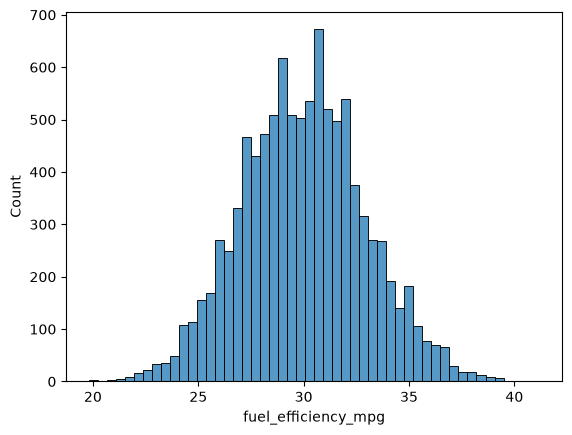

In [21]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)
plt.show()

### Preparing the dataset
Keep only the columns required by the homework.

In [22]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]
df = df[columns]
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


## Question 1: Missing values
Which column has missing values?

In [23]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [24]:
missing = df.isnull().sum()
print('Answer Q1:', list(missing[missing > 0].index))

Answer Q1: ['horsepower']


## Question 2: Median for horsepower

In [25]:
print('Answer Q2:', df['horsepower'].median())

Answer Q2: 254.0


## Split the data
Shuffle with seed 42, split 60% / 20% / 20%.

In [26]:
def split_data(df, seed):
    n = len(df)
    n_val = int(0.2 * n)
    n_test = int(0.2 * n)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx]
    df_train = df_shuffled.iloc[:n_train].reset_index(drop=True)
    df_val = df_shuffled.iloc[n_train:n_train + n_val].reset_index(drop=True)
    df_test = df_shuffled.iloc[n_train + n_val:].reset_index(drop=True)

    y_train = df_train.pop('fuel_efficiency_mpg').values
    y_val = df_val.pop('fuel_efficiency_mpg').values
    y_test = df_test.pop('fuel_efficiency_mpg').values

    return df_train, df_val, df_test, y_train, y_val, y_test

df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, seed=42)
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Helper functions

In [27]:
def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    w = np.linalg.inv(XTX).dot(X.T).dot(y)

    return w[0], w[1:]

def prepare_X(df, fillna_value):
    return df.fillna(fillna_value).values

def rmse(y, y_pred):
    return np.sqrt(((y_pred - y) ** 2).mean())

## Question 3: Filling NAs
Fill `horsepower` with 0 vs. with the **training-set** mean, train without regularization, compare validation RMSE (rounded to 2 decimals).

In [28]:
# Option 1: fill with 0
X_train = prepare_X(df_train, 0)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val, 0)
rmse_zero = round(rmse(y_val, w0 + X_val.dot(w)), 2)

# Option 2: fill with the mean (computed on train only)
mean_hp = df_train['horsepower'].mean()
X_train = prepare_X(df_train, mean_hp)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val, mean_hp)
rmse_mean = round(rmse(y_val, w0 + X_val.dot(w)), 2)

print('RMSE with 0:   ', rmse_zero)
print('RMSE with mean:', rmse_mean)

RMSE with 0:    2.21
RMSE with mean: 2.2


In [29]:
if rmse_zero < rmse_mean:
    print('Answer Q3: With 0')
elif rmse_mean < rmse_zero:
    print('Answer Q3: With mean')
else:
    print('Answer Q3: Both are equally good')

Answer Q3: With mean


## Question 4: Best regularization
Fill NAs with 0 and try different values of `r`. RMSE rounded to 2 decimals; if there's a tie, pick the smallest `r`.

In [30]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

scores = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(X_train, y_train, r=r)
    score = round(rmse(y_val, w0 + X_val.dot(w)), 2)
    scores[r] = score
    print(f'r={r:<6} RMSE={score}')

r=0      RMSE=2.21
r=0.01   RMSE=2.21
r=0.1    RMSE=2.22
r=1      RMSE=2.35
r=5      RMSE=2.41
r=10     RMSE=2.42
r=100    RMSE=2.43


In [31]:
best_r = min(scores, key=lambda r: (scores[r], r))
print('Answer Q4:', best_r)

Answer Q4: 0


## Question 5: RMSE standard deviation
Try seeds 0–9, fill NAs with 0, no regularization. Report the std of the validation RMSEs (rounded to 3 decimals).

In [32]:
rmses = []
for seed in range(10):
    df_tr, df_v, df_te, y_tr, y_v, y_te = split_data(df, seed=seed)
    w0, w = train_linear_regression(prepare_X(df_tr, 0), y_tr)
    score = rmse(y_v, w0 + prepare_X(df_v, 0).dot(w))
    rmses.append(score)
    print(seed, round(score, 4))

0 2.2392
1 2.2021
2 2.1634
3 2.2044
4 2.2019
5 2.2458
6 2.2697
7 2.1908
8 2.2166
9 2.207


In [33]:
print('Answer Q5:', round(np.std(rmses), 3))

Answer Q5: 0.029


## Question 6: Evaluation on test
Split with seed 9, combine train + validation, fill NAs with 0, train with `r=0.001`, and evaluate on test.

In [34]:
df_tr, df_v, df_te, y_tr, y_v, y_te = split_data(df, seed=9)

df_full_train = pd.concat([df_tr, df_v]).reset_index(drop=True)
y_full_train = np.concatenate([y_tr, y_v])

w0, w = train_linear_regression(prepare_X(df_full_train, 0), y_full_train, r=0.001)
test_rmse = rmse(y_te, w0 + prepare_X(df_te, 0).dot(w))
print('Answer Q6:', round(test_rmse, 3))

Answer Q6: 2.236


## Summary of answers

| Question | Answer |
|---|---|
| 1. Missing values | `horsepower` |
| 2. Median for horsepower | 254 |
| 3. Filling NAs | With mean (RMSE 2.20 vs 2.21 with 0) |
| 4. Best regularization | 0 (ties with 0.01 at 2.21; smallest r wins) |
| 5. RMSE standard deviation | 0.029 |
| 6. Evaluation on test | 2.236 |
